In [1]:
!pip install yfinance


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import yfinance as yf

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error


In [3]:
# Example stock: Apple (AAPL)
stock_symbol = "AAPL"
data = yf.download(stock_symbol, start="2015-01-01", end="2024-01-01")

print("Dataset Loaded Successfully")
data.head()


/tmp/ipython-input-2352084991.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(stock_symbol, start="2015-01-01", end="2024-01-01")
[*********************100%***********************]  1 of 1 completed

Dataset Loaded Successfully


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2015-01-02,24.214893,24.682226,23.776353,24.671151,212818400
2015-01-05,23.532726,24.064289,23.346680,23.984555,257142000
2015-01-06,23.534931,23.794068,23.173911,23.596947,263188400
2015-01-07,23.864948,23.964616,23.632389,23.743131,160423600
2015-01-08,24.781897,24.839483,24.075361,24.192749,237458000


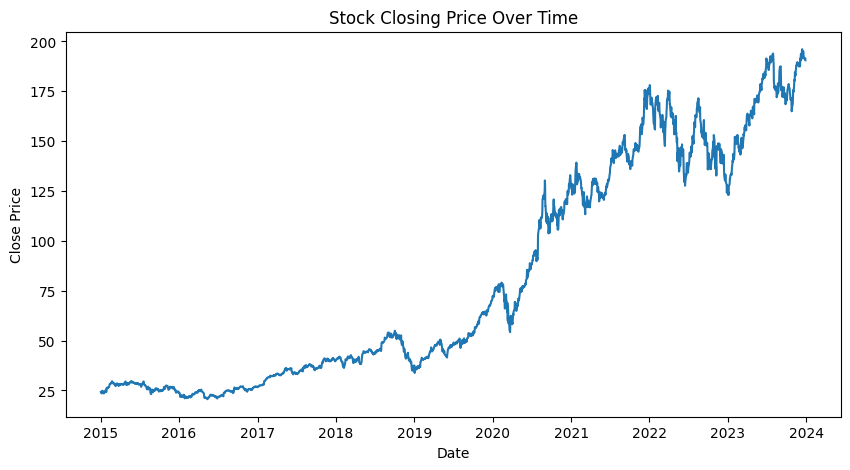

In [4]:
plt.figure(figsize=(10,5))
plt.plot(data['Close'])
plt.title("Stock Closing Price Over Time")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.show()


In [5]:
# Select closing price and remove missing values
close_price = data[['Close']]
close_price.dropna(inplace=True)


/tmp/ipython-input-4262500689.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  close_price.dropna(inplace=True)


In [6]:
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_close = scaler.fit_transform(close_price)


In [7]:
def create_sliding_window(data, window_size=5):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:i + window_size, 0])
        y.append(data[i + window_size, 0])
    return np.array(X), np.array(y)

window_size = 5
X, y = create_sliding_window(scaled_close, window_size)

print("Feature Matrix Shape (X):", X.shape)
print("Target Vector Shape (y):", y.shape)


Feature Matrix Shape (X): (2259, 5)
Target Vector Shape (y): (2259,)


In [8]:
train_size = int(len(X) * 0.8)

X_train = X[:train_size]
y_train = y[:train_size]

X_test = X[train_size:]
y_test = y[train_size:]

print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))


Training Samples: 1807
Testing Samples: 452


In [9]:
model = LinearRegression()

predictions = []
actuals = []

history_X = list(X_train)
history_y = list(y_train)

for i in range(len(X_test)):
    model.fit(np.array(history_X), np.array(history_y))

    y_pred = model.predict(X_test[i].reshape(1, -1))
    predictions.append(y_pred[0])
    actuals.append(y_test[i])

    history_X.append(X_test[i])
    history_y.append(y_test[i])


In [10]:
predictions = scaler.inverse_transform(
    np.array(predictions).reshape(-1, 1)
)

actuals = scaler.inverse_transform(
    np.array(actuals).reshape(-1, 1)
)


In [11]:
mse = mean_squared_error(actuals, predictions)
rmse = np.sqrt(mse)
mae = mean_absolute_error(actuals, predictions)

print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("Mean Absolute Error (MAE):", mae)


Mean Squared Error (MSE): 7.745823464550685
Root Mean Squared Error (RMSE): 2.7831319524145246
Mean Absolute Error (MAE): 2.098989166254603


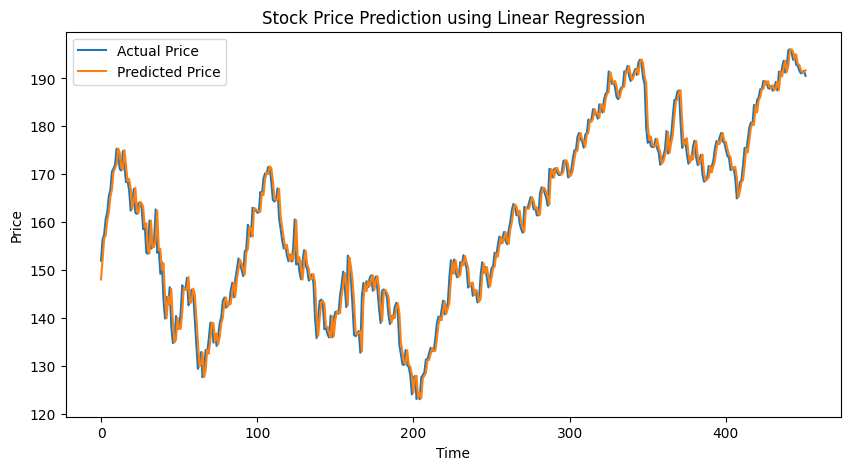

In [12]:
plt.figure(figsize=(10,5))
plt.plot(actuals, label='Actual Price')
plt.plot(predictions, label='Predicted Price')
plt.title("Stock Price Prediction using Linear Regression")
plt.xlabel("Time")
plt.ylabel("Price")
plt.legend()
plt.show()


In [13]:
last_window = scaled_close[-window_size:]
last_window = last_window.reshape(1, -1)

next_day_price = model.predict(last_window)
next_day_price = scaler.inverse_transform(
    next_day_price.reshape(-1, 1)
)

print("Predicted Next Day Stock Price:", next_day_price[0][0])


Predicted Next Day Stock Price: 190.68769179021746
